In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import files
uploaded = files.upload()


Saving alzheimer detection.v4-augmentation.folder.zip to alzheimer detection.v4-augmentation.folder.zip


In [18]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'alzheimer' in f.lower() and f.endswith('.zip'):
            print(os.path.join(root, f))


/content/drive/MyDrive/alzheimer detection.v4-augmentation.folder.zip


In [19]:
import zipfile
import os

# Path to your dataset in Google Drive
zip_path = '/content/drive/MyDrive/alzheimer detection.v4-augmentation.folder.zip'

# Where to extract it in Colab
extract_path = '/content/alzheimer_detection_v4_augmented'

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete!")
print("Contents:", os.listdir(extract_path))


✅ Extraction complete!
Contents: ['train', 'README.dataset.txt', 'README.roboflow.txt', 'valid', 'test']


In [2]:
#Importing libraries
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report


100%|██████████| 4/4 [00:00<00:00, 93.50it/s]
/tmp/ipython-input-1382502609.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.label, palette='Set1')


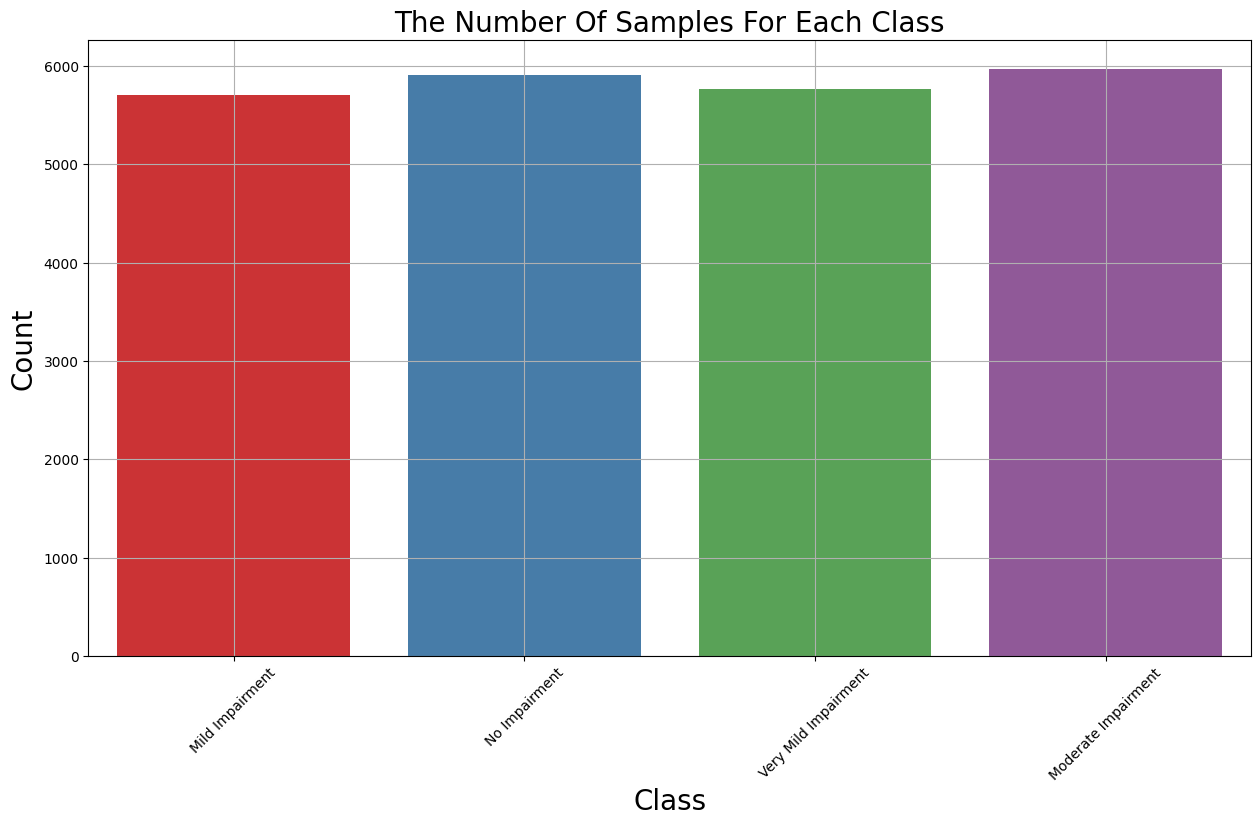

In [12]:
import os
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

images = []
labels = []

data_path = '/content/alzheimer_detection_v4_augmented/train'


for class_folder in tqdm(os.listdir(data_path)):
    class_folder_path = os.path.join(data_path, class_folder)
    if not os.path.isdir(class_folder_path):
        continue  # Skip if not a directory
    for image_filename in os.listdir(class_folder_path):
        image_path = os.path.join(class_folder_path, image_filename)
        images.append(image_path)
        labels.append(class_folder)

df = pd.DataFrame({'image': images, 'label': labels})

plt.figure(figsize=(15,8))
ax = sns.countplot(x=df.label, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels = le.fit_transform(df['label'])
X = df['image'].values
y = labels

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [14]:
train_dataset = AlzheimerMRIDataset(X_train, y_train, transform=transform)
val_dataset = AlzheimerMRIDataset(X_val, y_val, transform=transform)
test_dataset = AlzheimerMRIDataset(X_test, y_test, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [15]:
import torch
import torch.nn as nn

class AlzheimerCNN(nn.Module):
    def __init__(self):
        super(AlzheimerCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        # Calculate output size after CNN layers for linear layer
        self._to_linear = None
        self.get_conv_output()
        self.fc1 = nn.Linear(self._to_linear, 1024)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(1024, 4)  # Assuming 4 classes

    def get_conv_output(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, 176, 176)  # Input image shape
            x = self.pool1(torch.relu(self.conv1(x)))
            x = self.pool2(torch.relu(self.conv2(x)))
            x = self.pool3(torch.relu(self.conv3(x)))
            self._to_linear = x.numel()

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        x = x.view(-1, self._to_linear)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return torch.softmax(x, dim=1)


In [16]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

class AlzheimerMRIDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(cv2.resize(image, (176, 176)), cv2.COLOR_BGR2RGB)
        image = image.astype('float32') / 255.0
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# Define transforms
transform = transforms.Compose([transforms.ToTensor()])

# Split your balanced/final list of image paths and labels beforehand
# Example: X_train, y_train, X_val, y_val, X_test, y_test

train_dataset = AlzheimerMRIDataset(X_train, y_train, transform=transform)
val_dataset = AlzheimerMRIDataset(X_val, y_val, transform=transform)
test_dataset = AlzheimerMRIDataset(X_test, y_test, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlzheimerCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
epochs = 20
patience = 10
wait = 0

for epoch in range(epochs):
    model.train()
    train_loss, train_acc = 0, 0
    for images, labels in trainloader:
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        preds = torch.max(outputs, 1)[1]
        train_acc += torch.sum(preds == labels.data)
    train_loss /= len(trainloader.dataset)
    train_acc = float(train_acc) / len(trainloader.dataset)

    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device, dtype=torch.float)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = torch.max(outputs, 1)[1]
            val_acc += torch.sum(preds == labels.data)
    val_loss /= len(valloader.dataset)
    val_acc = float(val_acc) / len(valloader.dataset)

    print(f"Epoch {epoch+1} - Train loss {train_loss:.4f}, acc {train_acc:.4f} Val loss {val_loss:.4f}, acc {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping!")
            break

Epoch 1 - Train loss 1.2071, acc 0.4983 Val loss 1.0798, acc 0.6443
Epoch 2 - Train loss 1.0417, acc 0.6927 Val loss 1.0350, acc 0.6991
Epoch 3 - Train loss 1.0055, acc 0.7326 Val loss 1.0172, acc 0.7162
Epoch 4 - Train loss 0.9844, acc 0.7524 Val loss 0.9691, acc 0.7688
Epoch 5 - Train loss 0.9674, acc 0.7715 Val loss 0.9684, acc 0.7705
Epoch 6 - Train loss 0.9565, acc 0.7821 Val loss 0.9954, acc 0.7442
Epoch 7 - Train loss 0.9424, acc 0.7957 Val loss 0.9603, acc 0.7808
Epoch 8 - Train loss 0.9402, acc 0.7972 Val loss 0.9480, acc 0.7913
Epoch 9 - Train loss 0.9236, acc 0.8187 Val loss 0.9537, acc 0.7825
Epoch 10 - Train loss 0.9211, acc 0.8184 Val loss 0.9452, acc 0.7953
Epoch 11 - Train loss 0.9194, acc 0.8214 Val loss 0.9444, acc 0.7959
Epoch 12 - Train loss 0.9160, acc 0.8240 Val loss 0.9419, acc 0.7990
Epoch 13 - Train loss 0.9075, acc 0.8326 Val loss 0.9318, acc 0.8056
Epoch 14 - Train loss 0.9081, acc 0.8330 Val loss 0.9250, acc 0.8156
Epoch 15 - Train loss 0.9015, acc 0.8393 Va

Confusion Matrix:
 [[725   0  29 103]
 [  1 886   0   8]
 [ 86   7 577 217]
 [ 73   2 145 645]]


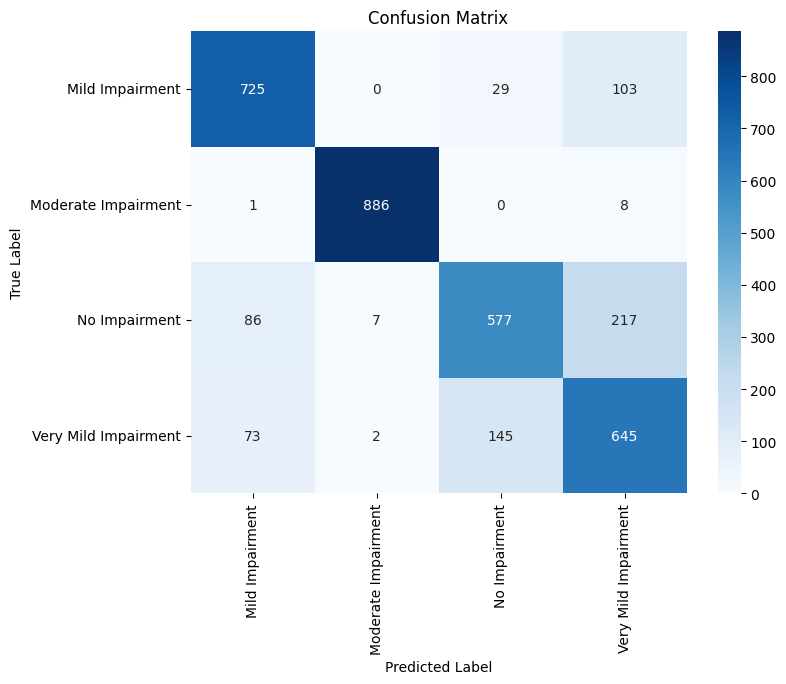

Classification Report:
                       precision    recall  f1-score   support

     Mild Impairment       0.82      0.85      0.83       857
 Moderate Impairment       0.99      0.99      0.99       895
       No Impairment       0.77      0.65      0.70       887
Very Mild Impairment       0.66      0.75      0.70       865

            accuracy                           0.81      3504
           macro avg       0.81      0.81      0.81      3504
        weighted avg       0.81      0.81      0.81      3504

Accuracy: 0.8085
Balanced Accuracy: 0.8080
Per Class Metrics:
Class: Mild Impairment
  Precision: 0.8192
  Recall (Sensitivity): 0.8460
  Specificity: 0.9396
  F1 Score: 0.8324
  Support: 857
Class: Moderate Impairment
  Precision: 0.9899
  Recall (Sensitivity): 0.9899
  Specificity: 0.9966
  F1 Score: 0.9899
  Support: 895
Class: No Impairment
  Precision: 0.7683
  Recall (Sensitivity): 0.6505
  Specificity: 0.9335
  F1 Score: 0.7045
  Support: 887
Class: Very Mild Impair

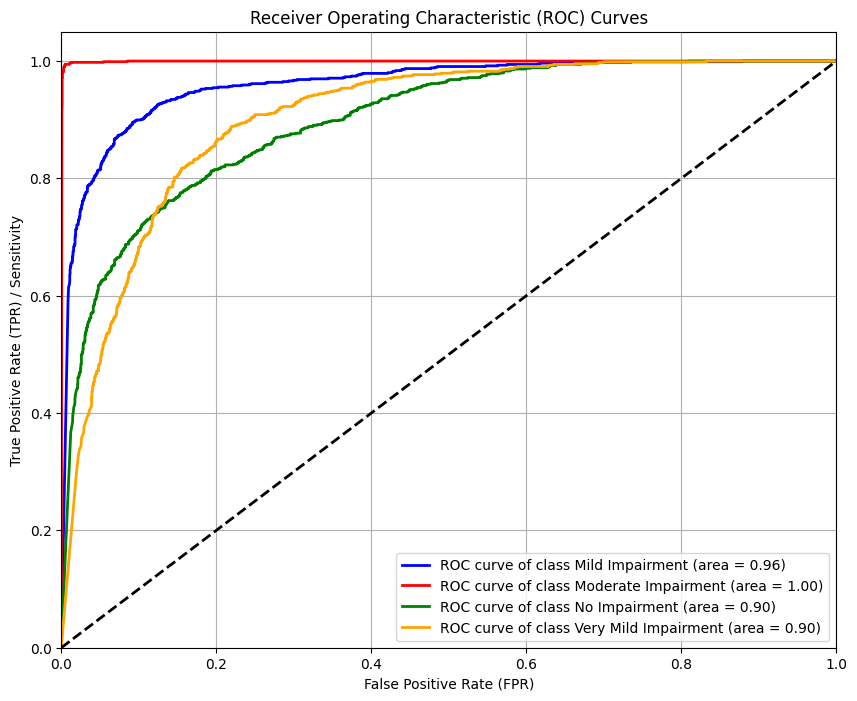


Class-wise Metrics:

Class: Mild Impairment
  TP: 725, FP: 160, TN: 2487, FN: 132
  True Positive Rate (Sensitivity): 0.8460
  False Positive Rate: 0.0604
  True Negative Rate (Specificity): 0.9396
  False Negative Rate: 0.1540
  ROC AUC: 0.9607

Class: Moderate Impairment
  TP: 886, FP: 9, TN: 2600, FN: 9
  True Positive Rate (Sensitivity): 0.9899
  False Positive Rate: 0.0034
  True Negative Rate (Specificity): 0.9966
  False Negative Rate: 0.0101
  ROC AUC: 0.9993

Class: No Impairment
  TP: 577, FP: 174, TN: 2443, FN: 310
  True Positive Rate (Sensitivity): 0.6505
  False Positive Rate: 0.0665
  True Negative Rate (Specificity): 0.9335
  False Negative Rate: 0.3495
  ROC AUC: 0.8981

Class: Very Mild Impairment
  TP: 645, FP: 328, TN: 2311, FN: 220
  True Positive Rate (Sensitivity): 0.7457
  False Positive Rate: 0.1243
  True Negative Rate (Specificity): 0.8757
  False Negative Rate: 0.2543
  ROC AUC: 0.9034


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import torch

# Load best model weights and set evaluation mode
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

preds = []
true_labels = []
probs = []

# Predict on test data
with torch.no_grad():
    for images, labels in testloader:  # Use 'testloader' as defined
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = outputs.cpu().numpy()
        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        probs.extend(probabilities)

true_labels = np.array(true_labels)
preds = np.array(preds)
probs = np.array(probs)

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
print("Confusion Matrix:\n", cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
cr = classification_report(true_labels, preds, target_names=le.classes_)
print("Classification Report:\n", cr)

# Accuracy Metrics
acc = accuracy_score(true_labels, preds)
print("Accuracy: {:.4f}".format(acc))

bal_acc = balanced_accuracy_score(true_labels, preds)
print("Balanced Accuracy: {:.4f}".format(bal_acc))

# Per-class Precision, Recall, F1-score, Specificity and Support
precision, recall, f1_score, support = precision_recall_fscore_support(true_labels, preds, average=None)
print("Per Class Metrics:")
for i, class_name in enumerate(le.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"Class: {class_name}")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall (Sensitivity): {recall[i]:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  F1 Score: {f1_score[i]:.4f}")
    print(f"  Support: {support[i]}")

# ROC-AUC and ROC Curve plotting
n_classes = len(le.classes_)
y_true_bin = label_binarize(true_labels, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC curve of class {le.classes_[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Class-wise Rates from Confusion Matrix
print("\nClass-wise Metrics:")
for i in range(n_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # Sensitivity, Recall
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0  # Specificity
    FNR = FN / (TP + FN) if (TP + FN) > 0 else 0

    print(f"\nClass: {le.classes_[i]}")
    print(f"  TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")
    print(f"  True Positive Rate (Sensitivity): {TPR:.4f}")
    print(f"  False Positive Rate: {FPR:.4f}")
    print(f"  True Negative Rate (Specificity): {TNR:.4f}")
    print(f"  False Negative Rate: {FNR:.4f}")
    print(f"  ROC AUC: {roc_auc[i]:.4f}")
